# Intent Classification: Fine-Tuning DistilBERT

This notebook implements a fine-tuning pipeline for the `distilbert-base-uncased` model to classify customer support queries into 27 intents. Fine-tuning a pre-trained transformer model leverages bidirectional self-attention to capture subtle semantic nuances, delivering high precision even on short or conversational queries.


### 1. Library Imports & Setup
We install Hugging Face's `evaluate` and `accelerate` libraries for standard evaluation metrics and efficient training. We then import standard data science and transformer tools.


In [42]:
!pip install -q evaluate accelerate


In [61]:
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, AutoTokenizer, pipeline
import evaluate


### 2. Loading Preprocessed Dataset
We load the cleaned training corpus containing user instructions and labels.


In [44]:
df = pd.read_csv("/kaggle/input/datasets/akshat14s/customer-support-intent-classification-dataset/cleaned_data_for_training.csv")


### 3. Stratified Train-Validation Split
We perform a stratified 80/20 train-validation split to preserve class representation across the 27 intents.


In [45]:
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, 
    stratify=df['label'], 
    random_state=42
)


### 4. Loading Tokenizer & Batch Dataset Prep
We load the pre-trained DistilBERT tokenizer and convert our pandas splits into Hugging Face `Dataset` objects. We define a tokenization mapping function with truncation and a max sequence length of 64 tokens.


In [46]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


In [47]:
train_dataset = Dataset.from_pandas(train_df[['cleaned_text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['cleaned_text', 'label']])


In [48]:
def tokenize_function(examples):
    return tokenizer(
        examples["cleaned_text"], 
        padding="max_length",
        truncation=True, 
        max_length=64
    )


### 5. Running Dataset Tokenization
We run the tokenization mapping function in batches over both splits.


In [49]:
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)


Map:   0%|          | 0/21497 [00:00<?, ? examples/s]

Map:   0%|          | 0/5375 [00:00<?, ? examples/s]

In [50]:
print(f"Data split and tokenized successfully!")
print(f"Training rows: {len(tokenized_train)} | Validation rows: {len(tokenized_val)}")


Data split and tokenized successfully!
Training rows: 21497 | Validation rows: 5375


### 6. Number of Classes Verification
We verify the total number of unique intent classes present in the labels.


In [51]:
NUM_LABELS = int(df['label'].nunique())
NUM_LABELS


27

### 7. Loading Pre-trained DistilBERT Model
We load `distilbert-base-uncased` with a sequence classification head configured for 27 labels.


In [52]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 8. Configuring Evaluation Metric
We load the accuracy metric and define a compute function to calculate argmax predictions from raw logits during evaluation epochs.


In [53]:
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)


### 9. Defining Training Hyperparameters
We configure the training arguments, using a learning rate of 2e-5, weight decay of 0.01, mixed-precision training (`fp16=True`) for optimal speed, and epoch-based evaluations.


In [54]:
training_args = TrainingArguments(
    output_dir="./distilbert_intent_model",
    learning_rate=2e-5,                  
    per_device_train_batch_size=32,      
    per_device_eval_batch_size=32,
    num_train_epochs=3,                  
    weight_decay=0.01,
    eval_strategy="epoch",         
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True, # Uses Kaggle's GPU tensor cores for lightning-fast training
    report_to="none"                     
)


### 10. Initializing Trainer
We instantiate the Hugging Face `Trainer` with our model, training arguments, tokenized splits, and evaluation metric.


In [55]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)


### 11. Executing Model Fine-Tuning
We run the training pipeline, monitoring train loss, validation loss, and accuracy metrics at each epoch.


In [56]:
print("Starting training run...")
trainer.train()


Starting training run...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.219713,0.992744
2,1.727250,0.048021,0.996465
3,0.052914,0.036313,0.997023


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1008, training_loss=0.8832635241486724, metrics={'train_runtime': 271.005, 'train_samples_per_second': 237.97, 'train_steps_per_second': 3.719, 'total_flos': 1068345474198912.0, 'train_loss': 0.8832635241486724, 'epoch': 3.0})

### 12. Saving Model & Tokenizer to Disk
Once fine-tuning completes, we save the model weights and tokenizer configurations to a local directory.


In [58]:
trainer.save_model("./distilbert_intent_classification")
tokenizer.save_pretrained("./distilbert_intent_classification")
print("Model successfully saved to disk!")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model successfully saved to disk!


### 13. Setting up Inference Pipeline
We map numerical IDs back to their human-readable intent text names using the class JSON mapping. We then load the model and instantiate a pipeline classifier for evaluation.


In [62]:
with open("/kaggle/input/datasets/akshat14s/customer-support-intent-classification-dataset/label_mapping.json", "r") as f:
    raw_mapping = json.load(f)

id2label = {int(k): v for k, v in raw_mapping.items()}
label2id = {v: int(k) for k, v in raw_mapping.items()}

MODEL_PATH = "./distilbert_intent_classification"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)


In [63]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    ignore_mismatched_sizes=True
)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [64]:
classifier = pipeline(
    "text-classification", 
    model=model, 
    tokenizer=tokenizer,
)


### 14. Stress Testing Live Inference
We define conversational test queries containing typos and greeting fluff to evaluate the classifier's prediction confidence in real-world settings.


In [66]:
test_queries = [
    "hello customer service department i am writing this long message because i urgently need to delete my account due to personal reasons",
    "i cannot seem to log back in because it says wrong credentials",
    "i need to cancel my subscrie immediately tfack",
    "my paidx transaction went wrong please give me a refund",
    "how do i change my login password",
    "refund pls paidx broke",
    "forgor my passwrd",
    "chnge my shippin addres",
    "close my acount noww",
    "double chargd on card",
    "sign in lockd",
    "where is my pakage",
    "cancel sub now",
    "report a bugg",
    "money back mony",
    
    # --- Long / Conversational Queries with Fluff and Typos ---
    "hi team i have been using this platform for 3 years but now i want to permantly delte my profile account because i am switching to a competitor",
    "good morning every time i try to log into my dashboard using my verified email it keeps giving me a system validation error saying access denied even though the password is correct",
    "please stop my premium auto renewal subscription i do not want to be billd again next month thanks",
    "i bought an item yesterday but it arrived completely broken and damaged i demand a full refnd immediately to my original payment method",
    "i am writing this because i completely lost access to the recovery email address associated with my profile and now i desperately need to resset my security password to get back in",
    "i accidentally put the wrong street number when checking out last night can you please update the delivery address before the item gets shipped out from the warehouse",
    "trackin number says delivered but i havent received anything at my doorstep yet please check what went wrong with my ordr",
    "hey i tried applying the promotional coupon code during checkout but the system threw an invalid discunt error can you apply it manually",
    "my screen turns completely blank whenever i input my username and hit the sign-in button on the mobile application interface please assist",
    "i need to update my legal name and contact phone number on the profile settings dashboard because i recently got marrid and changed my details"
]

print("\n--- DISTILBERT LIVE STRESS TEST RESULTS ---")
for query in test_queries:
    result = classifier(query)[0]
    print(f"\nQuery: '{query}'")
    print(f" -> Predicted Intent: '{result['label']}' | Confidence: {result['score'] * 100:.2f}%")


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



--- DISTILBERT LIVE STRESS TEST RESULTS ---

Query: 'hello customer service department i am writing this long message because i urgently need to delete my account due to personal reasons'
 -> Predicted Intent: 'delete_account' | Confidence: 92.03%

Query: 'i cannot seem to log back in because it says wrong credentials'
 -> Predicted Intent: 'change_shipping_address' | Confidence: 33.41%

Query: 'i need to cancel my subscrie immediately tfack'
 -> Predicted Intent: 'cancel_order' | Confidence: 86.03%

Query: 'my paidx transaction went wrong please give me a refund'
 -> Predicted Intent: 'get_refund' | Confidence: 88.27%

Query: 'how do i change my login password'
 -> Predicted Intent: 'recover_password' | Confidence: 98.97%

Query: 'refund pls paidx broke'
 -> Predicted Intent: 'get_refund' | Confidence: 90.13%

Query: 'forgor my passwrd'
 -> Predicted Intent: 'recover_password' | Confidence: 92.34%

Query: 'chnge my shippin addres'
 -> Predicted Intent: 'change_shipping_address' | Con

### 15. Classification Performance Evaluation
We compute predictions across the entire validation dataset and generate a confusion matrix and classification report.


Extracting parallel predictions from the validation set...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


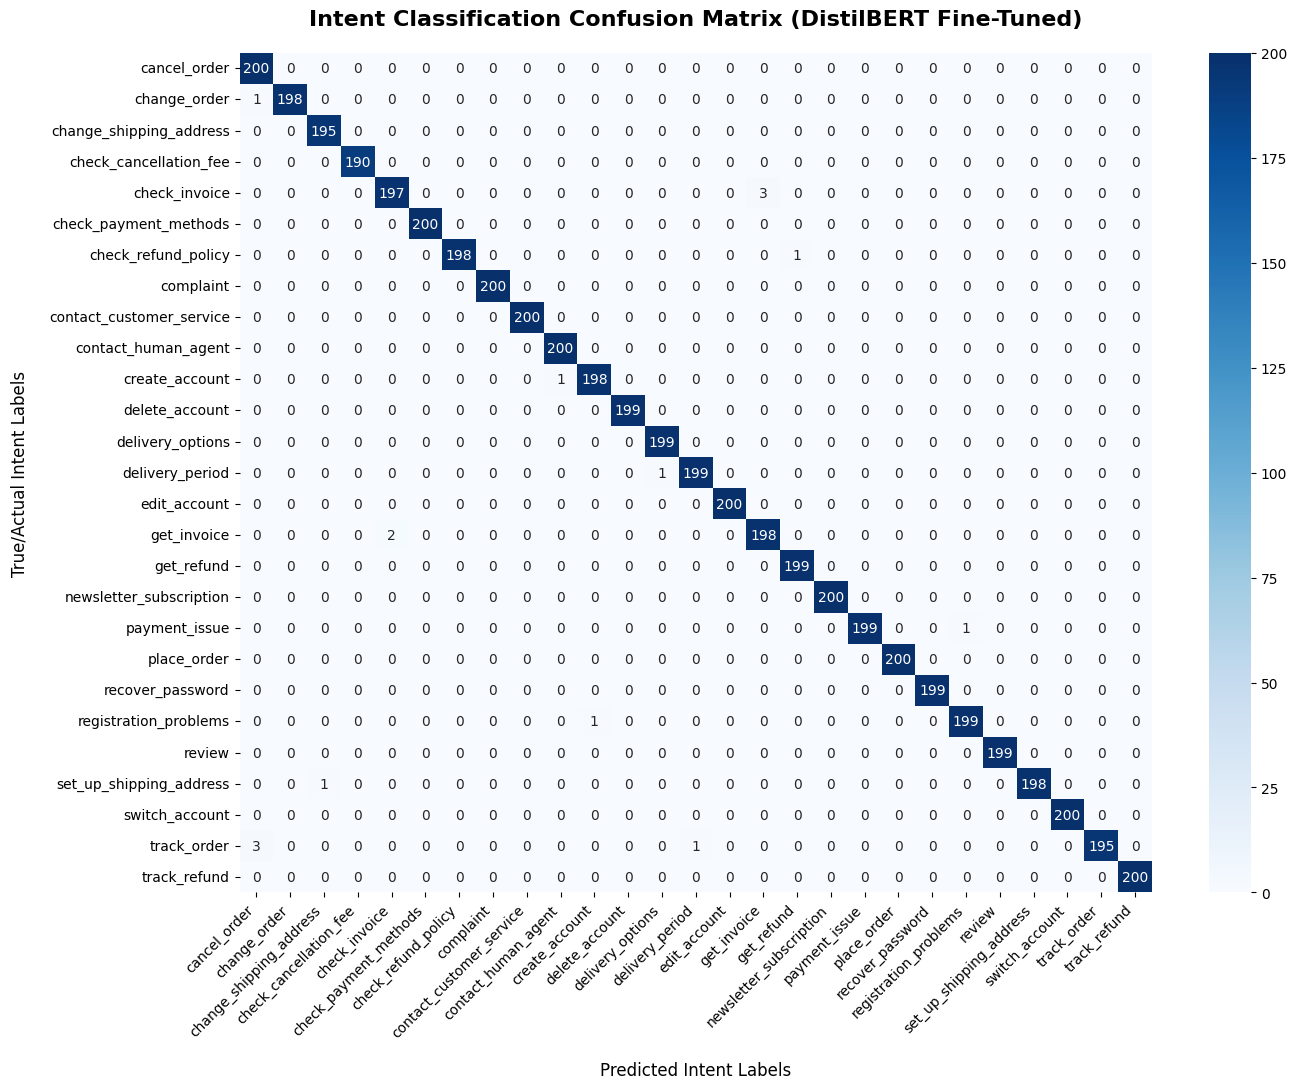


--- DETAILED ARCHITECTURAL PERFORMANCE REPORT ---
                          precision    recall  f1-score   support

            cancel_order       0.98      1.00      0.99       200
            change_order       1.00      0.99      1.00       199
 change_shipping_address       0.99      1.00      1.00       195
  check_cancellation_fee       1.00      1.00      1.00       190
           check_invoice       0.99      0.98      0.99       200
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       1.00      0.99      1.00       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      1.00      1.00       200
     contact_human_agent       1.00      1.00      1.00       200
          create_account       0.99      0.99      0.99       199
          delete_account       1.00      1.00      1.00       199
        delivery_options       0.99      1.00      1.00       199
         delivery_period

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

print("Extracting parallel predictions from the validation set...")
output = trainer.predict(tokenized_val)

raw_predictions = output.predictions
true_labels = output.label_ids

predicted_labels = np.argmax(raw_predictions, axis=-1)

# (Uses the id2label dictionary we pulled from your label_mapping.json)
class_names = [id2label[i] for i in sorted(id2label.keys())]

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=class_names, 
    yticklabels=class_names,
    cbar=True
)

plt.title("Intent Classification Confusion Matrix (DistilBERT Fine-Tuned)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Predicted Intent Labels", fontsize=12, labelpad=15)
plt.ylabel("True/Actual Intent Labels", fontsize=12, labelpad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n--- DETAILED ARCHITECTURAL PERFORMANCE REPORT ---")
print(classification_report(true_labels, predicted_labels, target_names=class_names))


### 16. Pushing Model to Hugging Face Hub
We install `huggingface_hub` to push our fine-tuned classifier, tokenizers, configurations, and metric cards to the public Hub.


In [68]:
!pip install huggingface_hub -q


In [69]:
from huggingface_hub import notebook_login
notebook_login()


In [70]:
trainer.push_to_hub("distilbert-customer-care-intent-classifier")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/akshatdev14/distilbert_intent_model/commit/b76c3d36708d8e7317e8e0f292ea9ef42d8232b3', commit_message='distilbert-customer-care-intent-classifier', commit_description='', oid='b76c3d36708d8e7317e8e0f292ea9ef42d8232b3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/akshatdev14/distilbert_intent_model', endpoint='https://huggingface.co', repo_type='model', repo_id='akshatdev14/distilbert_intent_model'), pr_revision=None, pr_num=None)